In [15]:
#Trevor Henderson, Faith Yang
#dataset: https://www.kaggle.com/datasets/larsen0966/penguins

#import my libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
## part 1 load data
#import and drop rows missing items
raw=pd.read_csv('penguins_size.csv').dropna().reset_index(drop=True)

#convert strings in species and map them to numeric (0,1,2)
species_map = {s: i for i, s in enumerate(sorted(raw['species'].unique()))}
labels = raw['species'].map(species_map).values.reshape(-1,1)









In [16]:
## part 2 data frame
#these are the important feature name columns
feature_names = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

#combines the measurment and new numeric values back together in one table with labels
df = pd.DataFrame(
      np.concatenate([raw[feature_names].values, labels], axis=1),
      columns=np.append(feature_names, 'label')
)

#print the new shape and print top 5 rows to make sure it looks right
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (334, 5)
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  label
0              39.1             18.7              181.0       3750.0    0.0
1              39.5             17.4              186.0       3800.0    0.0
2              40.3             18.0              195.0       3250.0    0.0
3              36.7             19.3              193.0       3450.0    0.0
4              39.3             20.6              190.0       3650.0    0.0


In [17]:
## part 3 normalize
#normalize data so to mean = 0 and std = 1 so that PCA can be done
features = feature_names
x = StandardScaler().fit_transform(df[features])

print("\nNormalized data - Mean: {:.4f}, Std: {:.4f}".format(np.mean(x), np.std(x)))


Normalized data - Mean: 0.0000, Std: 1.0000


In [18]:
## part 4 PCA
#reducing the 4 features to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x)

pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])

print("\nExplained variance per component:")
print(" PC1: {:.1%} | PC2: {:.1%}".format(*pca.explained_variance_ratio_))



Explained variance per component:
 PC1: 68.6% | PC2: 19.4%


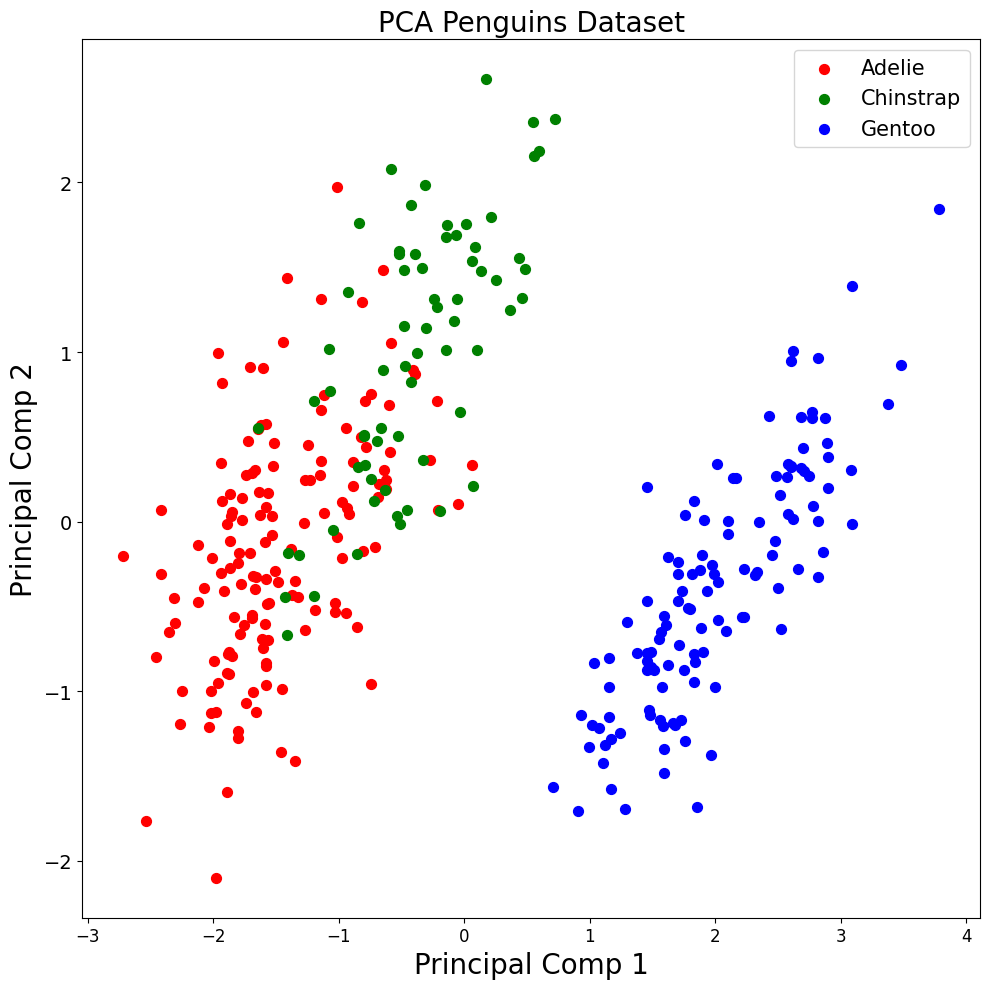


Plot saved as png


In [ ]:
## part 5 Graph it
#make it look pretty on a graph with well separated clusters
plt.figure(figsize=(10,10))
plt.xlabel('Principal Comp 1', fontsize=20)
plt.ylabel('Principal Comp 2', fontsize=20)
plt.title('PCA Penguins Dataset', fontsize=20)
plt.xticks(fontsize=12); plt.yticks(fontsize=14)

colors = {0: ('r', 'Adelie'), 1: ('g', 'Chinstrap'), 2: ('b', 'Gentoo')}
for label, (color, name) in colors.items():
  mask = df['label'] == label
  plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
              c=color, s=50, label=name)
plt.legend(prop = {'size': 15})
plt.tight_layout()
plt.savefig('pca_penguins.png', dpi=150)
plt.show()
print("\nPlot saved as png")

#Lab 4 explnation
#We used a penguins species documentation dataset to see if PCA would allow us to identify different species by measurements alone.
#PCA allows you to take 4 measurements of penguins and compress them down into 2.
#This allows them to be easily plotted on a graph for a visual representation.
#This graph shows that Gentoo penguins are easily identifiable compared to the other types.
#Adelie and Chinstrap penguins are too similar in measurements to identify them based on size.
#Doing this allows for a quick visual way to understand differences before doing more analysis.

